# Proyek Analisis Data: E-commerse Public Dataset
- **Nama:** T.Sofia Chairani
- **Email:** tsofiachairani@gmail.com
- **ID Dicoding:** t-sofiachairani

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh dimensi produk (weight, length, height dan width) terhadap waktu pengiriman pada transaksi e-commerse selama periode 2017-2018?
- Bagaimana pengaruh biaya pengiriman terhadap waktu pengiriman pada transaksi e-commerce selama periode 2017-2018?

## Import Semua Packages/Library yang Digunakan

In [ ]:
# Gathering Data
from google.colab import files
import os, shutil
import pandas as pd

# Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
upload_dir = "/content/E-Commerce_Public_Dataset"
os.makedirs(upload_dir, exist_ok=True)

uploaded = files.upload()

for filename in uploaded:
    shutil.move(
        f"/content/{filename}",
        os.path.join(upload_dir, filename)
    )

print("File tersimpan di:", upload_dir)

Saving order_items_dataset.csv to order_items_dataset.csv
Saving order_payments_dataset.csv to order_payments_dataset.csv
Saving order_reviews_dataset.csv to order_reviews_dataset.csv
Saving orders_dataset.csv to orders_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv
Saving products_dataset.csv to products_dataset.csv
Saving sellers_dataset.csv to sellers_dataset.csv
Saving customers_dataset.csv to customers_dataset.csv
Saving geolocation_dataset.csv to geolocation_dataset.csv
File tersimpan di: /content/E-Commerce_Public_Dataset


In [ ]:
path = "/content/E-Commerce_Public_Dataset/"

df_orders, df_order_items, df_products = (
    pd.read_csv(path + "orders_dataset.csv"),
    pd.read_csv(path + "order_items_dataset.csv"),
    pd.read_csv(path + "products_dataset.csv")
)

In [ ]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
df_order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
# column selection
# df_orders
df_orders = df_orders[[
    "order_id",
    "order_purchase_timestamp",
    "order_delivered_customer_date"
]]

# df_order_items
df_order_items = df_order_items[[
    "order_id",
    "product_id",
    "freight_value"
]]

# df_products
df_products = df_products[[
    "product_id",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]]

**Insight:**
Pada proyek analisis data ini, dataset dan kolom yang digunakan adalah df_orders, df_order_items, df_products disesuaikan dengan pertanyaan bisnis yang sudah dirumuskan di awal.
- Dataset df_orders berisi informasi utama mengenai transaksi e-commerce seperti waktu pembelian dan waktu pesanan diterima pelanggan. Data ini akan digunakan untuk menghitung durasi waktu pengiriman pada setiap transaksi.
- Dataset df_order_items berisi detail item dalam setiap pesanan, termasuk harga produk dan biaya pengiriman. Data ini digunakan untuk menganalisis pengaruh biaya pengiriman terhadap waktu pengiriman serta menghubungkan pesanan dengan produk yang dibeli.
- Dataset df_products berisi informasi karakteristik produk seperti berat dan dimensi produk (length, height, width). Data ini digunakan untuk menganalisis pengaruh dimensi produk terhadap waktu pengiriman pada transaksi e-commerce.

### Assessing Data

In [ ]:
# cek missing value
df_orders.isna().sum()

,0
order_id,0
order_purchase_timestamp,0
order_delivered_customer_date,2965


In [ ]:
# cek data duplikat
df_orders.duplicated().sum()

np.int64(0)

In [ ]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   order_purchase_timestamp       99441 non-null  datetime64[ns]
 2   order_delivered_customer_date  96476 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(1)
memory usage: 2.3+ MB


In [ ]:
# ubah tipe data object menjadi datetime
df_orders["order_purchase_timestamp"] = pd.to_datetime(df_orders["order_purchase_timestamp"])
df_orders["order_delivered_customer_date"] = pd.to_datetime(df_orders["order_delivered_customer_date"])

In [ ]:
# validasi timestamp
pd.Series({
    "delivery_after_purchase":
        (df_orders["order_delivered_customer_date"] >=
         df_orders["order_purchase_timestamp"]).dropna().all()
})

,0
delivery_after_purchase,False


In [ ]:
df_orders.describe()

,order_purchase_timestamp,order_delivered_customer_date
count,99441,96476
mean,2017-12-31 08:43:12.776581120,2018-01-14 12:09:19.035542272
min,2016-09-04 21:15:19,2016-10-11 13:46:32
25%,2017-09-12 14:46:19,2017-09-25 22:07:22.249999872
50%,2018-01-18 23:04:36,2018-02-02 19:28:10.500000
75%,2018-05-04 15:42:16,2018-05-15 22:48:52.249999872
max,2018-10-17 17:30:18,2018-10-17 13:22:46


In [ ]:
Q1 = df_orders["order_purchase_timestamp"].quantile(0.25)
Q3 = df_orders["order_purchase_timestamp"].quantile(0.75)
IQR = Q3 - Q1

outliers = df_orders[
    (df_orders["order_purchase_timestamp"] < (Q1 - 1.5 * IQR)) |
    (df_orders["order_purchase_timestamp"] > (Q3 + 1.5 * IQR))
]

len(outliers)

4

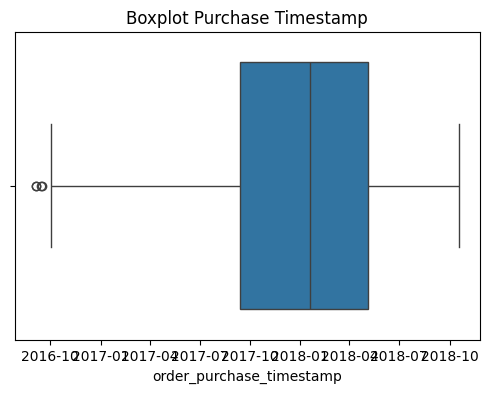

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_orders["order_purchase_timestamp"])
plt.title("Boxplot Purchase Timestamp")
plt.show()

In [ ]:
Q1 = df_orders["order_delivered_customer_date"].quantile(0.25)
Q3 = df_orders["order_delivered_customer_date"].quantile(0.75)
IQR = Q3 - Q1

outliers = df_orders[
    (df_orders["order_delivered_customer_date"] < (Q1 - 1.5 * IQR)) |
    (df_orders["order_delivered_customer_date"] > (Q3 + 1.5 * IQR))
]

len(outliers)

2

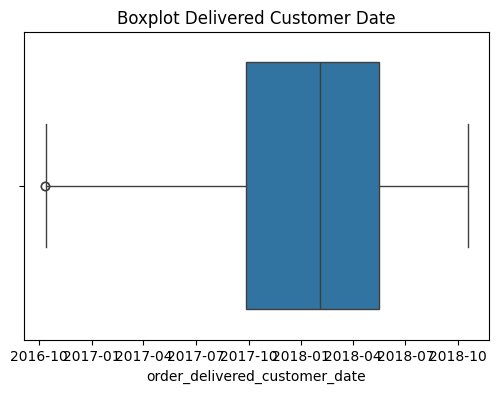

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_orders["order_delivered_customer_date"])
plt.title("Boxplot Delivered Customer Date")
plt.show()

In [ ]:
# cek missing value
df_order_items.isna().sum()

,0
order_id,0
product_id,0
freight_value,0


In [ ]:
# cek data duplikat
df_order_items.duplicated().sum()

np.int64(10225)

In [ ]:
df_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_id       112650 non-null  object 
 1   product_id     112650 non-null  object 
 2   freight_value  112650 non-null  float64
dtypes: float64(1), object(2)
memory usage: 2.6+ MB


In [ ]:
# validasi nilai
pd.Series({
    "freight_positive": (df_order_items["freight_value"] >= 0).all()
})

,0
freight_positive,True


In [ ]:
df_order_items.describe()

,freight_value
count,112650.000000
mean,19.990320
std,15.806405
min,0.000000
25%,13.080000
50%,16.260000
75%,21.150000
max,409.680000


In [ ]:
# cek outlier
Q1 = df_order_items["freight_value"].quantile(0.25)
Q3 = df_order_items["freight_value"].quantile(0.75)
IQR = Q3 - Q1

outliers = df_order_items[
    (df_order_items["freight_value"] < (Q1 - 1.5 * IQR)) |
    (df_order_items["freight_value"] > (Q3 + 1.5 * IQR))
]

len(outliers)

12134

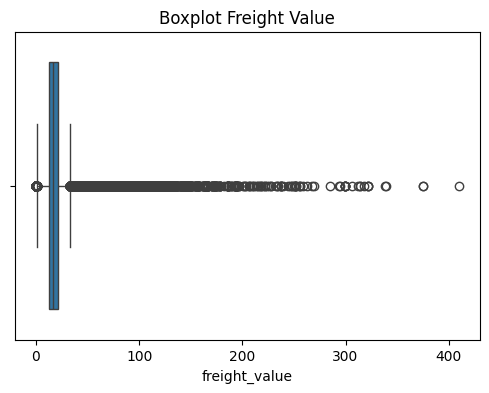

In [ ]:
# visualisasi outlier
plt.figure(figsize=(6,4))
sns.boxplot(x=df_order_items["freight_value"])
plt.title("Boxplot Freight Value")
plt.show()

In [ ]:
# cek missing value
df_products.isna().sum()

,0
product_id,0
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
df_products.duplicated().sum()

np.int64(0)

In [ ]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         32951 non-null  object 
 1   product_weight_g   32949 non-null  float64
 2   product_length_cm  32949 non-null  float64
 3   product_height_cm  32949 non-null  float64
 4   product_width_cm   32949 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.3+ MB


In [ ]:
# validasi nilai
pd.Series({
    "weight_positive": (df_products["product_weight_g"] > 0).all(),
    "length_positive": (df_products["product_length_cm"] > 0).all(),
    "height_positive": (df_products["product_height_cm"] > 0).all(),
    "width_positive": (df_products["product_width_cm"] > 0).all()
})

,0
weight_positive,False
length_positive,False
height_positive,False
width_positive,False


In [ ]:
df_products.describe()

,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32949.000000,32949.000000,32949.000000,32949.000000
mean,2276.472488,30.815078,16.937661,23.196728
std,4282.038731,16.914458,13.637554,12.079047
min,0.000000,7.000000,2.000000,6.000000
25%,300.000000,18.000000,8.000000,15.000000
50%,700.000000,25.000000,13.000000,20.000000
75%,1900.000000,38.000000,21.000000,30.000000
max,40425.000000,105.000000,105.000000,118.000000


In [ ]:
# cek outlier
Q1 = df_products["product_weight_g"].quantile(0.25)
Q3 = df_products["product_weight_g"].quantile(0.75)
IQR = Q3 - Q1

outliers = df_products[
    (df_products["product_weight_g"] < (Q1 - 1.5 * IQR)) |
    (df_products["product_weight_g"] > (Q3 + 1.5 * IQR))
]

len(outliers)

4551

In [ ]:
# cek outlier
Q1 = df_products["product_length_cm"].quantile(0.25)
Q3 = df_products["product_length_cm"].quantile(0.75)
IQR = Q3 - Q1

outliers = df_products[
    (df_products["product_length_cm"] < (Q1 - 1.5 * IQR)) |
    (df_products["product_length_cm"] > (Q3 + 1.5 * IQR))
]

len(outliers)

1380

In [ ]:
# cek outlier
Q1 = df_products["product_height_cm"].quantile(0.25)
Q3 = df_products["product_height_cm"].quantile(0.75)
IQR = Q3 - Q1

outliers = df_products[
    (df_products["product_height_cm"] < (Q1 - 1.5 * IQR)) |
    (df_products["product_height_cm"] > (Q3 + 1.5 * IQR))
]

len(outliers)

1892

In [ ]:
# cek outlier
Q1 = df_products["product_width_cm"].quantile(0.25)
Q3 = df_products["product_width_cm"].quantile(0.75)
IQR = Q3 - Q1

outliers = df_products[
    (df_products["product_width_cm"] < (Q1 - 1.5 * IQR)) |
    (df_products["product_width_cm"] > (Q3 + 1.5 * IQR))
]

len(outliers)

912

**Insight:**
- Dataset df_orders memiliki 99.441 transaksi dengan dua kolom waktu utama. Terdapat 2.965 missing values pada order_delivered_customer_date yang kemungkinan berasal dari pesanan yang dibatalkan atau belum dikirim. Tidak ditemukan data duplikat, namun validasi timestamp menunjukkan masih ada beberapa urutan waktu yang tidak konsisten.
- Dataset df_order_items berisi 112.650 data item pesanan dan tidak memiliki missing values. Terdapat 10.225 data duplikat, yang kemungkinan terjadi karena satu pesanan dapat memiliki lebih dari satu produk. Nilai freight_value seluruhnya valid (tidak negatif), namun terdapat beberapa outlier biaya pengiriman.
- Dataset df_products berisi 32.951 produk dengan informasi dimensi produk. Terdapat 2 missing values pada setiap kolom dimensi, serta beberapa nilai dimensi yang tidak valid seperti berat produk bernilai 0. Selain itu, ditemukan outlier pada beberapa dimensi produk, terutama pada berat produk.

### Cleaning Data

In [ ]:
# hapus missing value
df_orders = df_orders.dropna(subset=["order_delivered_customer_date"])
df_products = df_products.dropna()

In [ ]:
# pastikan urutan waktu valid
df_orders = df_orders[
    df_orders["order_delivered_customer_date"] >= df_orders["order_purchase_timestamp"]
]

In [ ]:
# hapus duplikat
df_order_items = df_order_items.drop_duplicates()

In [ ]:
# hapus freight negatif
df_order_items = df_order_items[df_order_items["freight_value"] >= 0]

In [ ]:
# hapus nilai dimensi yang tidak valid
df_products = df_products[
    (df_products["product_weight_g"] > 0) &
    (df_products["product_length_cm"] > 0) &
    (df_products["product_height_cm"] > 0) &
    (df_products["product_width_cm"] > 0)
]

**Insight:**
- Pada dataset df_orders, dilakukan penghapusan data dengan nilai kosong pada kolom order_delivered_customer_date karena kolom tersebut diperlukan untuk menghitung durasi waktu pengiriman. Selain itu, data dengan urutan waktu yang tidak logis, yaitu waktu penerimaan pesanan lebih awal daripada waktu pembelian, juga dihapus agar analisis waktu pengiriman menjadi lebih valid.
- Pada dataset df_order_items, dilakukan penghapusan data duplikat untuk menghindari perhitungan yang berulang pada analisis biaya pengiriman. Selain itu, dilakukan validasi nilai freight_value untuk memastikan tidak terdapat biaya pengiriman bernilai negatif.
- Pada dataset df_products, dilakukan penghapusan data yang memiliki nilai kosong pada dimensi produk serta nilai dimensi yang tidak valid (seperti berat atau ukuran bernilai nol). Hal ini dilakukan agar data dimensi produk yang digunakan dalam analisis benar-benar merepresentasikan karakteristik fisik produk.

Meskipun ditemukan outlier pada biaya pengiriman dan dimensi produk, data tersebut tidak dihapus karena masih mungkin merepresentasikan kondisi nyata seperti produk berukuran besar atau pengiriman dengan jarak yang jauh.

## Exploratory Data Analysis (EDA)

### Explore ...

In [ ]:
# merge data
df = df_order_items.merge(df_products, on="product_id", how="inner")
df = df.merge(df_orders, on="order_id", how="inner")

In [ ]:
# variabel waktu pengiriman
df["delivery_time"] = (
    df["order_delivered_customer_date"] -
    df["order_purchase_timestamp"]
).dt.days

In [ ]:
# statistik deskriptif
df[[
    "delivery_time",
    "freight_value",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]].describe()

,delivery_time,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,100173.000000,100173.000000,100173.000000,100173.000000,100173.000000,100173.000000
mean,12.031306,20.069688,2086.119423,30.071317,16.368572,23.028151
std,9.532682,15.782476,3739.751580,16.065999,13.271897,11.727848
min,0.000000,0.000000,2.000000,7.000000,2.000000,6.000000
25%,6.000000,13.140000,300.000000,18.000000,8.000000,15.000000
50%,10.000000,16.320000,700.000000,25.000000,13.000000,20.000000
75%,15.000000,21.190000,1800.000000,38.000000,20.000000,30.000000
max,209.000000,409.680000,40425.000000,105.000000,105.000000,118.000000


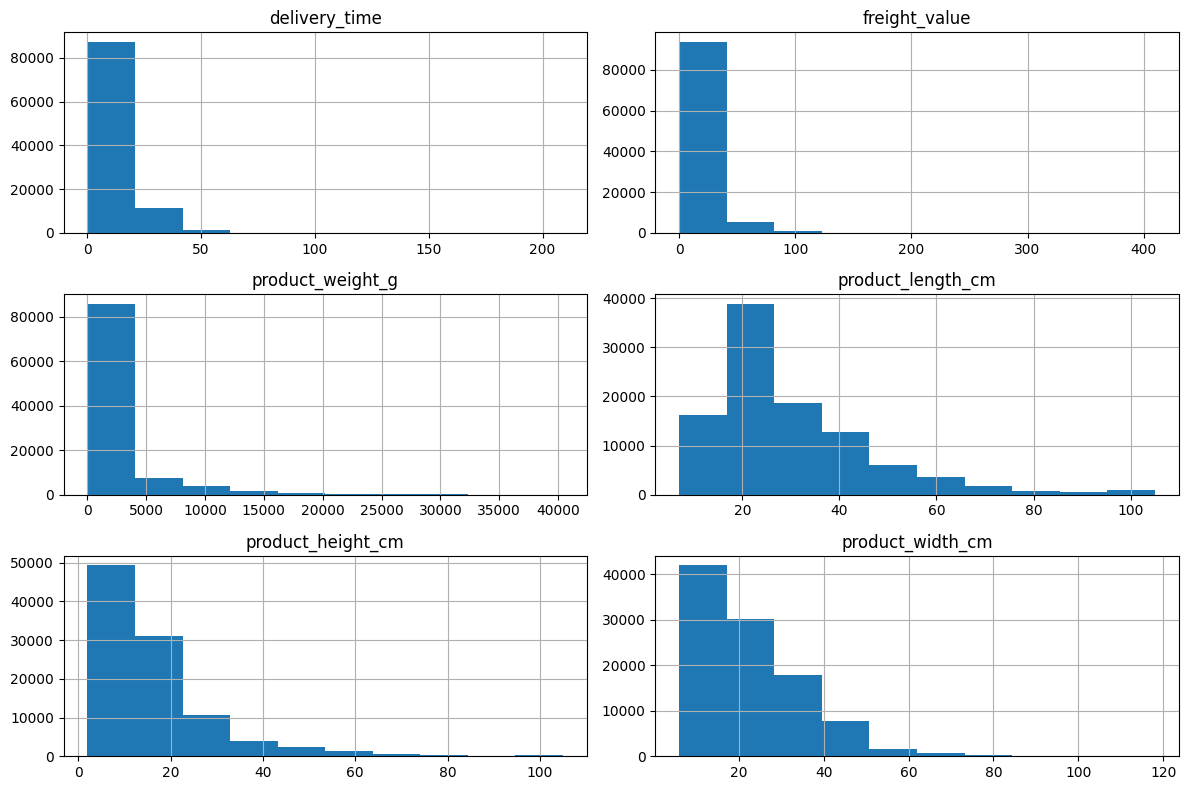

In [ ]:
# distribusi variabel
num_cols = [
    "delivery_time",
    "freight_value",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

df[num_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

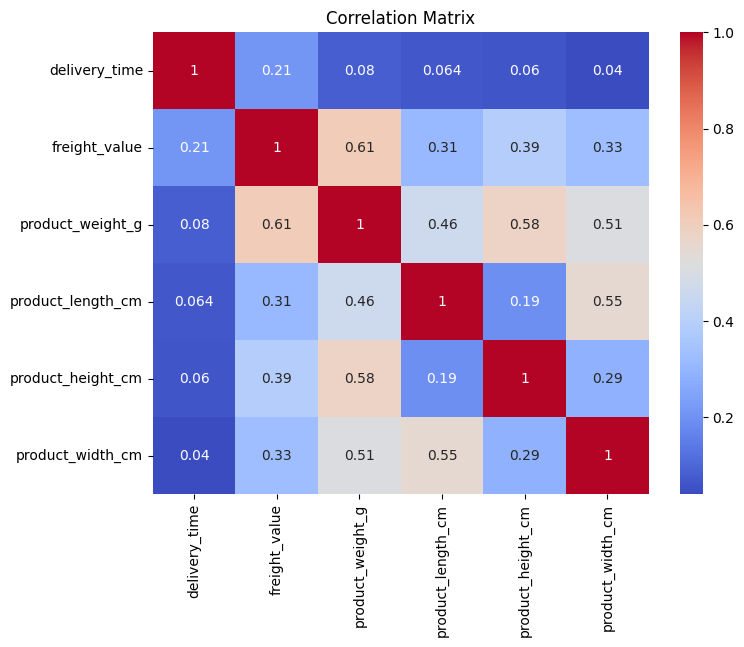

In [ ]:
#korelasi antar variabel
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**Insight:**
- Hasil statistik deskriptif menunjukkan bahwa rata-rata waktu pengiriman (delivery_time) sekitar 12 hari, dengan median sekitar 10 hari. Namun terdapat beberapa transaksi dengan waktu pengiriman yang sangat lama hingga 209 hari, yang menunjukkan adanya variasi waktu pengiriman yang cukup besar.
- Variabel freight_value memiliki rata-rata sekitar 20, dengan sebagian besar nilai berada di bawah 25, meskipun terdapat beberapa nilai ekstrem hingga 409, yang menunjukkan adanya perbedaan biaya pengiriman yang cukup signifikan pada beberapa transaksi.
- Dimensi produk menunjukkan variasi yang cukup besar. Rata-rata berat produk sekitar 2086 gram, dengan beberapa produk memiliki berat yang jauh lebih besar dibandingkan mayoritas produk lainnya. Hal yang sama juga terlihat pada dimensi panjang, tinggi, dan lebar produk yang memiliki rentang nilai yang cukup luas.
- Distribusi variabel menunjukkan bahwa sebagian besar data terkonsentrasi pada nilai yang relatif kecil dengan beberapa nilai ekstrem. Hal ini menunjukkan adanya right-skewed distribution pada beberapa variabel seperti berat produk dan biaya pengiriman.
- Analisis korelasi menunjukkan bahwa biaya pengiriman memiliki korelasi positif terhadap waktu pengiriman, meskipun hubungan tersebut tidak terlalu kuat. Selain itu, dimensi produk seperti berat, panjang, tinggi, dan lebar juga menunjukkan hubungan tertentu dengan biaya pengiriman dan waktu pengiriman.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

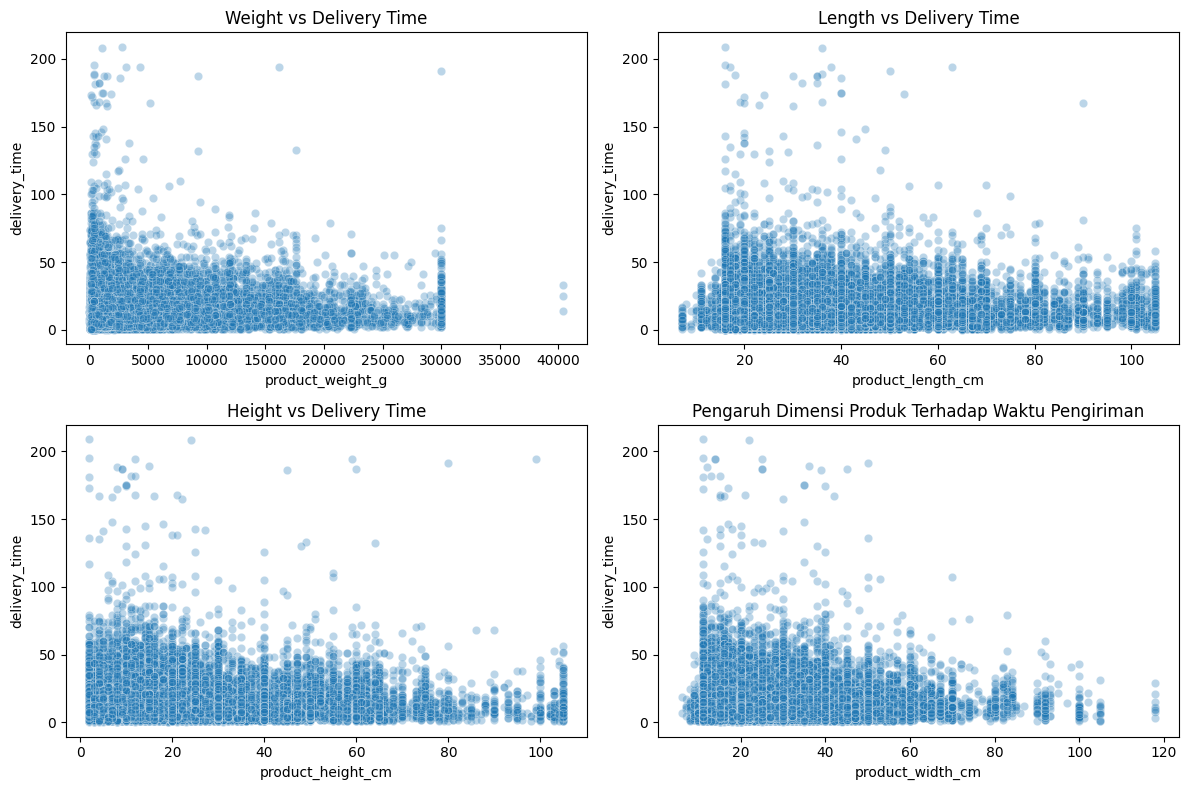

In [ ]:
# Visualisasi pengaruh dimensi produk terhadap waktu pengiriman
fig, axes = plt.subplots(2,2, figsize=(12,8))

sns.scatterplot(x="product_weight_g", y="delivery_time", data=df, ax=axes[0,0], alpha=0.3)
axes[0,0].set_title("Weight vs Delivery Time")

sns.scatterplot(x="product_length_cm", y="delivery_time", data=df, ax=axes[0,1], alpha=0.3)
axes[0,1].set_title("Length vs Delivery Time")

sns.scatterplot(x="product_height_cm", y="delivery_time", data=df, ax=axes[1,0], alpha=0.3)
axes[1,0].set_title("Height vs Delivery Time")

sns.scatterplot(x="product_width_cm", y="delivery_time", data=df, ax=axes[1,1], alpha=0.3)
axes[1,1].set_title("Width vs Delivery Time")

plt.tight_layout()
plt.show()

**Insight:**
- Visualisasi menunjukkan bahwa sebagian besar transaksi memiliki waktu pengiriman di bawah 50 hari, terlepas dari variasi dimensi produk. Hal ini menunjukkan bahwa sebagian besar proses pengiriman berlangsung dalam waktu yang relatif cepat.
- Variabel berat produk (product_weight_g) menunjukkan variasi yang cukup besar, namun tidak terlihat pola hubungan yang kuat dengan waktu pengiriman. Produk dengan berat yang lebih besar tidak selalu memiliki waktu pengiriman yang lebih lama.
- Pada dimensi panjang, tinggi, dan lebar produk, distribusi data juga menunjukkan pola yang relatif menyebar tanpa tren yang jelas. Hal ini mengindikasikan bahwa dimensi fisik produk bukan satu-satunya faktor yang mempengaruhi waktu pengiriman.
- Meskipun terdapat beberapa transaksi dengan waktu pengiriman yang sangat lama (outlier), nilai tersebut tersebar pada berbagai ukuran produk. Hal ini menunjukkan bahwa keterlambatan pengiriman kemungkinan lebih dipengaruhi oleh faktor lain seperti jarak pengiriman, lokasi penjual dan pembeli, atau proses logistik.

Kesimpulan:
Dimensi produk seperti berat, panjang, tinggi, dan lebar memiliki pengaruh yang relatif lemah terhadap waktu pengiriman, sehingga kemungkinan terdapat faktor lain yang lebih dominan dalam menentukan durasi pengiriman pada transaksi e-commerce.

### Pertanyaan 2:

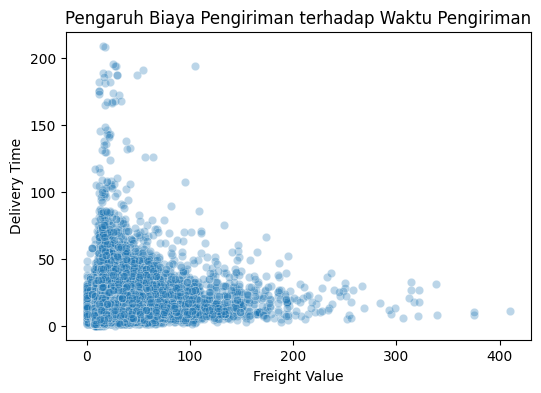

In [ ]:
# Visualisasi pengaruh dimensi produk terhadap waktu pengiriman
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="freight_value",
    y="delivery_time",
    data=df,
    alpha=0.3
)

plt.title("Pengaruh Biaya Pengiriman terhadap Waktu Pengiriman")
plt.xlabel("Freight Value")
plt.ylabel("Delivery Time")
plt.show()

**Insight:**
- Visualisasi menunjukkan bahwa sebagian besar transaksi memiliki biaya pengiriman di bawah 100 dengan waktu pengiriman yang relatif pendek, umumnya di bawah 50 hari.
- Terdapat kecenderungan bahwa transaksi dengan biaya pengiriman yang lebih tinggi memiliki variasi waktu pengiriman yang lebih kecil, sedangkan pada biaya pengiriman yang rendah terlihat variasi waktu pengiriman yang lebih besar.
- Beberapa transaksi dengan waktu pengiriman sangat lama terlihat pada biaya pengiriman yang relatif rendah, yang kemungkinan dipengaruhi oleh faktor lain seperti jarak pengiriman, lokasi geografis, atau proses logistik.
- Secara umum, tidak terlihat hubungan yang sangat kuat antara biaya pengiriman dan waktu pengiriman, meskipun terdapat indikasi bahwa transaksi dengan biaya pengiriman yang lebih tinggi cenderung memiliki waktu pengiriman yang lebih stabil.

Kesimpulan:
Biaya pengiriman memiliki hubungan yang relatif lemah terhadap waktu pengiriman, sehingga waktu pengiriman kemungkinan dipengaruhi oleh faktor lain seperti jarak pengiriman, lokasi penjual dan pembeli, serta proses distribusi logistik.

## Analisis Lanjutan: Clustering (Binning)

In [ ]:
# freight cost clustering
df["freight_cluster"] = pd.cut(
    df["freight_value"],
    bins=[0,20,50,100,500],
    labels=["Cluster 1 (Low Cost)",
            "Cluster 2 (Medium Cost)",
            "Cluster 3 (High Cost)",
            "Cluster 4 (Very High Cost)"]
)

In [ ]:
df.groupby("freight_cluster")["delivery_time"].mean()

/tmp/ipykernel_179/654863761.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("freight_cluster")["delivery_time"].mean()


,delivery_time
freight_cluster,
Cluster 1 (Low Cost),10.727673
Cluster 2 (Medium Cost),15.153713
Cluster 3 (High Cost),16.345863
Cluster 4 (Very High Cost),18.500000


In [ ]:
# product volume clustering
df["product_volume"] = (
    df["product_length_cm"] *
    df["product_height_cm"] *
    df["product_width_cm"]
)

df["volume_cluster"] = pd.qcut(
    df["product_volume"],
    q=4,
    labels=[
        "Cluster 1 (Small Package)",
        "Cluster 2 (Medium Package)",
        "Cluster 3 (Large Package)",
        "Cluster 4 (Very Large Package)"
    ]
)

In [ ]:
df.groupby("volume_cluster")["delivery_time"].mean()

/tmp/ipykernel_179/3483741001.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("volume_cluster")["delivery_time"].mean()


,delivery_time
volume_cluster,
Cluster 1 (Small Package),11.403076
Cluster 2 (Medium Package),11.845357
Cluster 3 (Large Package),11.866047
Cluster 4 (Very Large Package),13.021088


In [ ]:
df.to_csv("final_dataset.csv", index=False)

## Conclusion

Pertanyaan 1
> Bagaimana pengaruh dimensi produk (weight, length, height dan width) terhadap waktu pengiriman pada transaksi e-commerce selama periode 2017-2018?
- Temuan: Hasil clustering berdasarkan volume produk menunjukkan bahwa ukuran paket memiliki pengaruh terhadap waktu pengiriman. Produk dengan ukuran paket yang lebih besar cenderung memiliki rata-rata waktu pengiriman yang sedikit lebih lama dibandingkan paket yang lebih kecil. Cluster paket kecil memiliki rata-rata waktu pengiriman sekitar 11,4 hari, sedangkan paket sangat besar mencapai sekitar 13 hari. Hal ini menunjukkan bahwa dimensi produk dapat mempengaruhi proses logistik dan penanganan paket, meskipun pengaruhnya tidak terlalu besar.
- Rekomendasi: Marketplace atau perusahaan logistik dapat mengelompokkan paket berdasarkan ukuran (small, medium, large) untuk menentukan metode pengiriman yang paling efisien. Dengan strategi ini, paket besar dapat ditangani menggunakan jalur distribusi khusus agar tidak memperlambat proses pengiriman.

Pertanyaan 2
> Bagaimana pengaruh biaya pengiriman terhadap waktu pengiriman pada transaksi e-commerce selama periode 2017-2018?
- Temuan: Clustering berdasarkan biaya pengiriman menunjukkan bahwa rata-rata waktu pengiriman meningkat seiring dengan meningkatnya kategori biaya pengiriman. Cluster biaya pengiriman rendah memiliki rata-rata waktu pengiriman sekitar 10,7 hari, sedangkan cluster biaya sangat tinggi mencapai sekitar 18,5 hari. Hal ini menunjukkan bahwa transaksi dengan biaya pengiriman lebih tinggi cenderung memiliki waktu pengiriman yang lebih lama, yang kemungkinan dipengaruhi oleh faktor seperti jarak pengiriman yang lebih jauh atau kompleksitas distribusi.
- Rekomendasi: Platform e-commerce dapat memberikan estimasi waktu pengiriman yang lebih akurat berdasarkan jarak, biaya pengiriman, dan lokasi pelanggan. Hal ini dapat meningkatkan kepuasan pelanggan karena ekspektasi waktu pengiriman lebih jelas. Perusahaan juga dapat mengevaluasi struktur biaya pengiriman untuk memastikan bahwa biaya yang lebih tinggi memberikan layanan pengiriman yang lebih baik atau lebih cepat. Jika tidak, perlu dilakukan optimasi agar biaya pengiriman tetap kompetitif tanpa memperpanjang waktu pengiriman.

